In [7]:
#analysis of AN network model with stimulation  FigS15

import os
import sys
import matplotlib.pyplot as plt
from scipy import integrate

from tqdm import tqdm


#from vistats import annotate_bracket
import math
from scipy.signal import find_peaks
from scipy.signal import periodogram



from scipy import signal
import scipy
import statistics as stat

import math
import pickle
import gc
import traceback


from collections import deque
import itertools
import numpy as np
import pandas as pd


sys.path.append('../')
sys.path.append('../anmodel')


import anmodel

import pickle



fs = 20
fs_l = 15


OK
OK


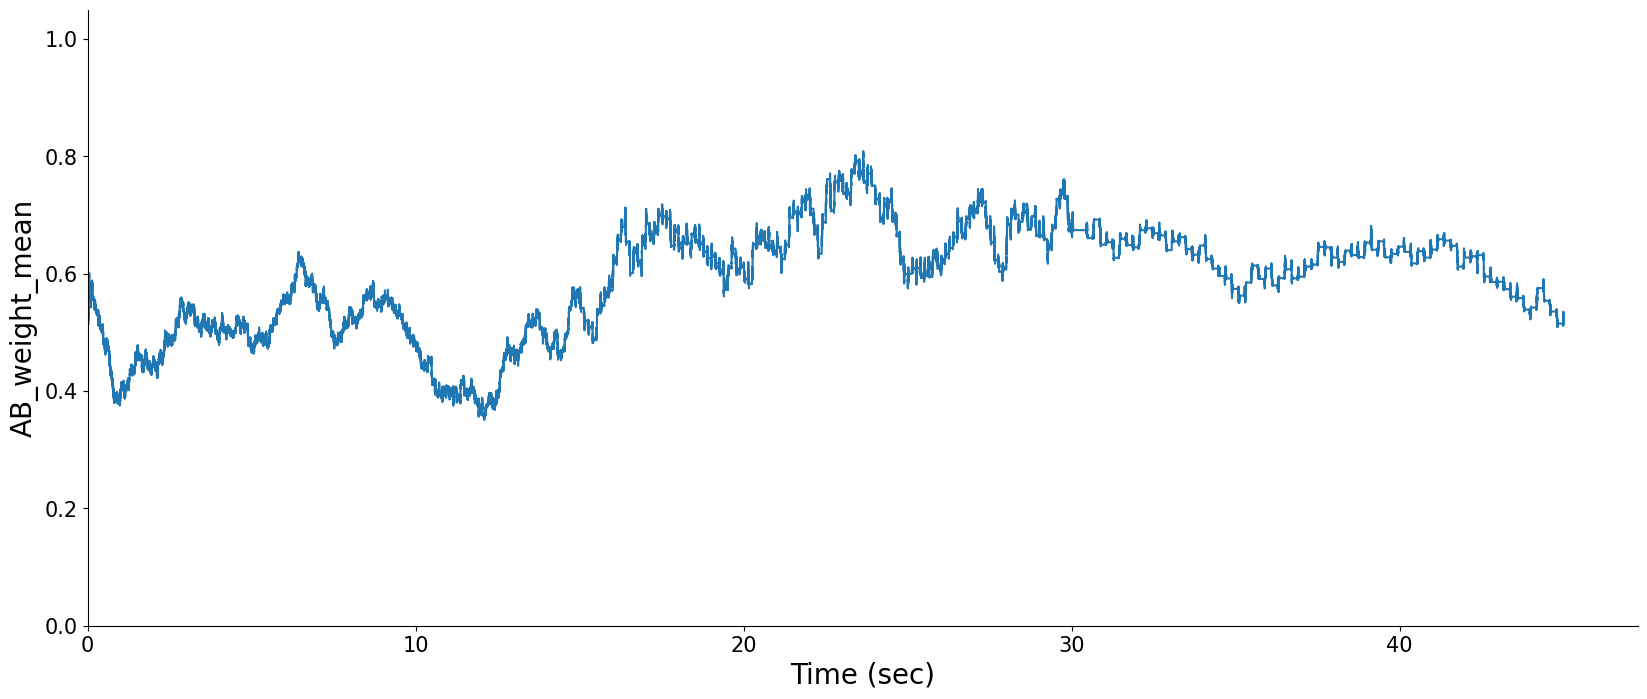

0.51775295


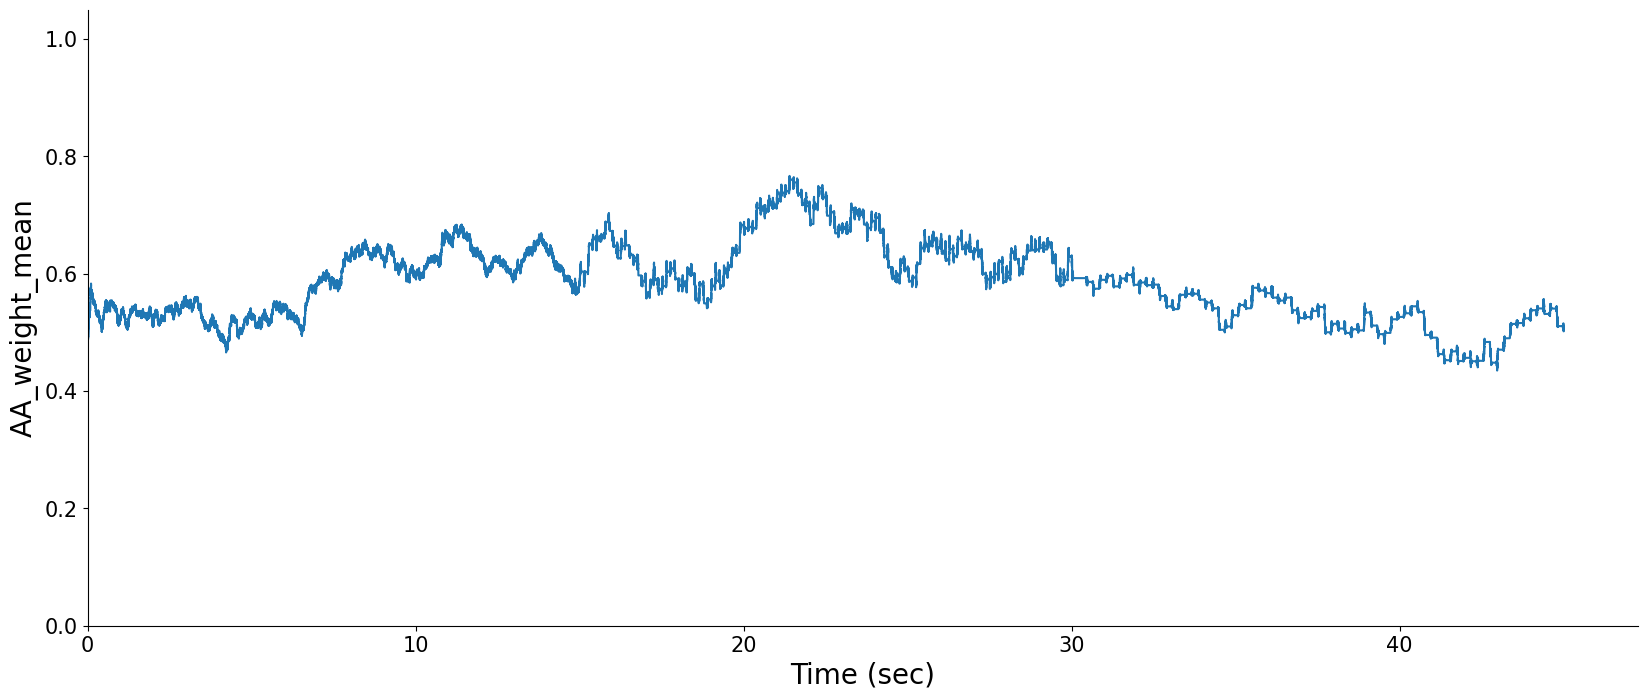

0.5071478


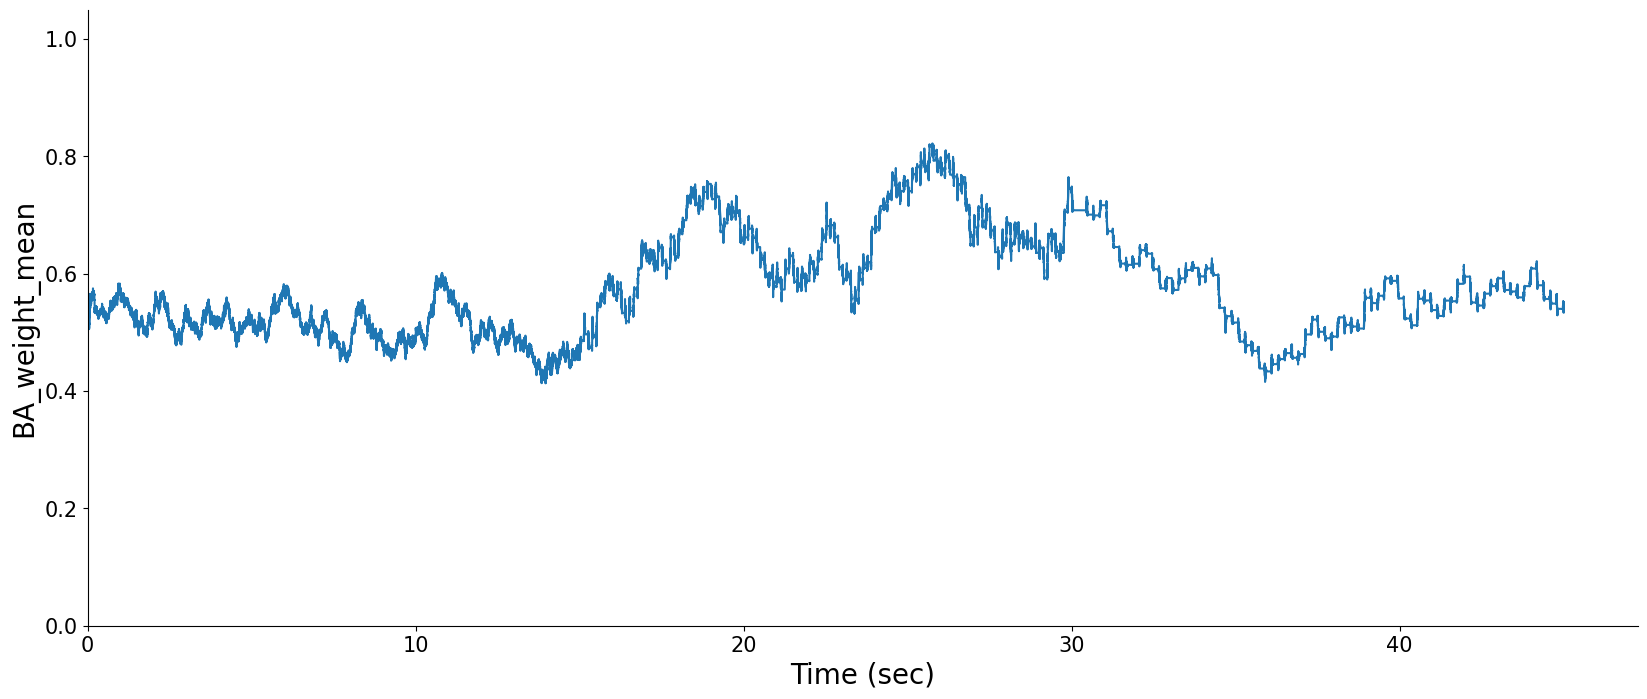

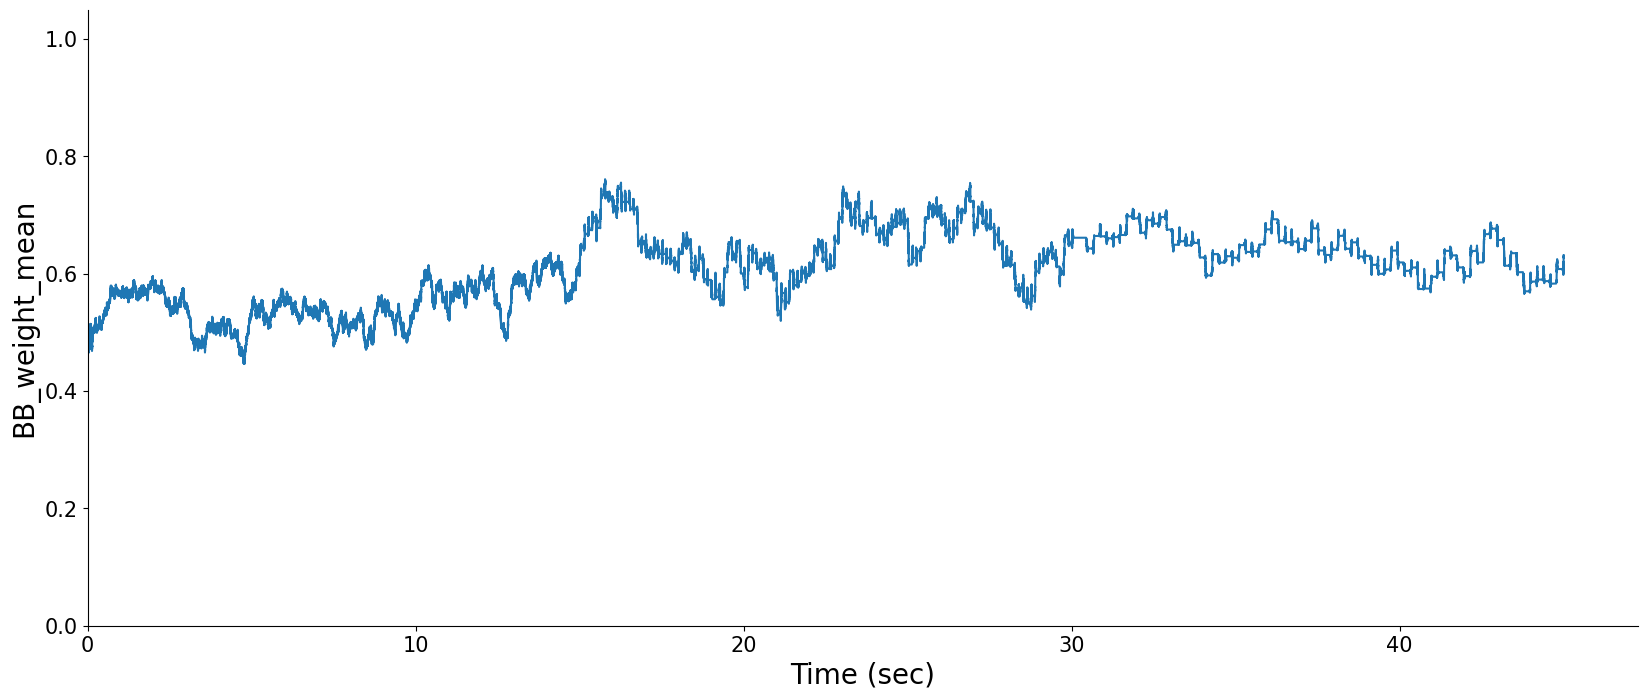

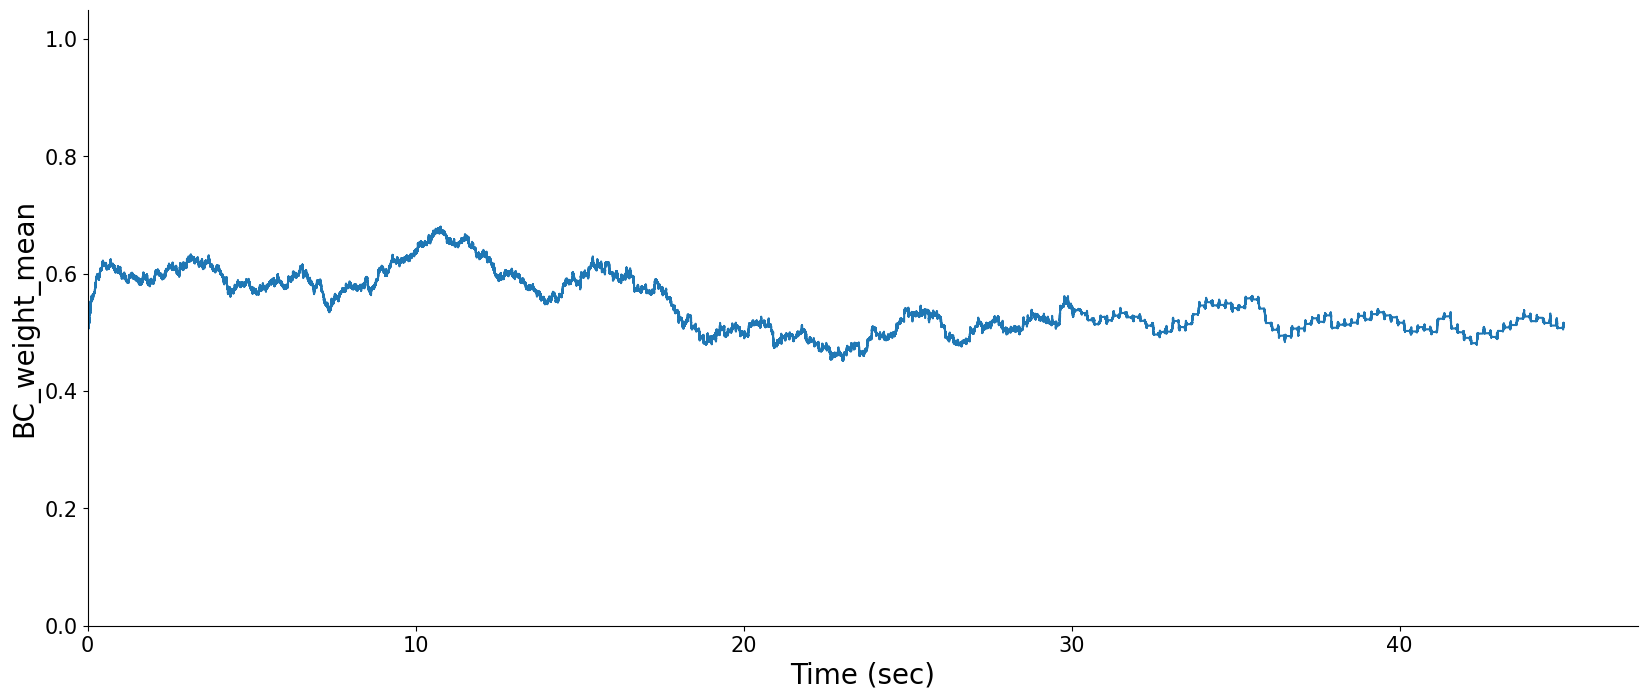

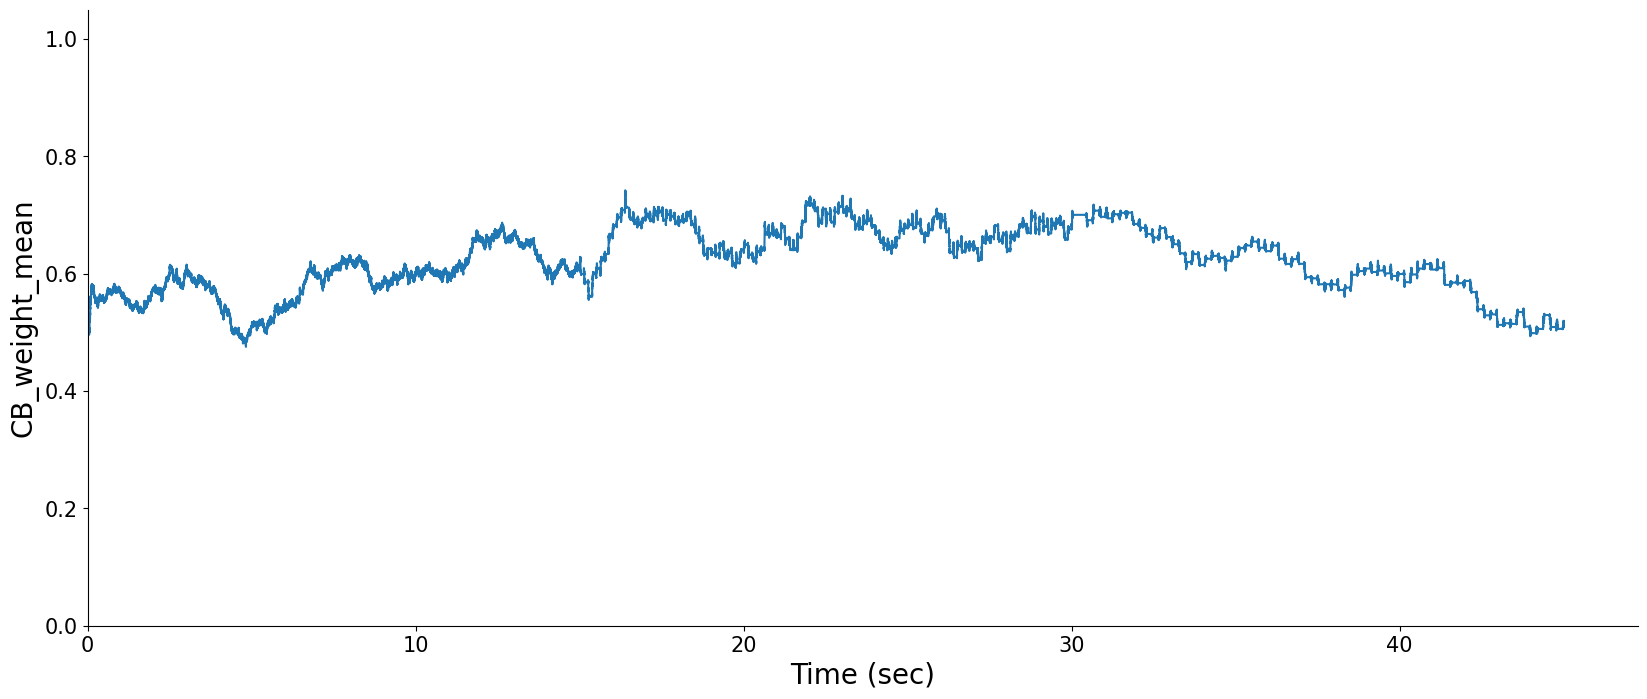

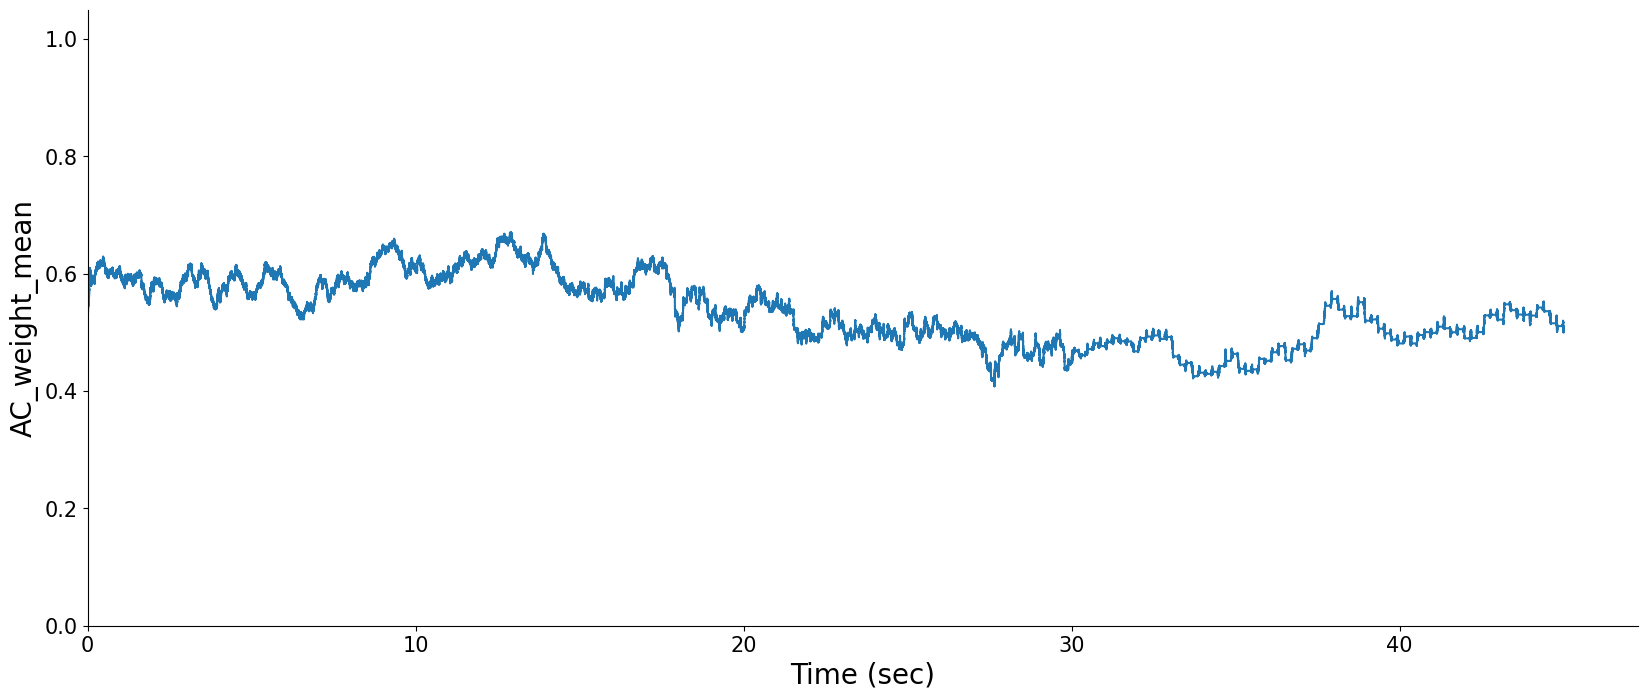

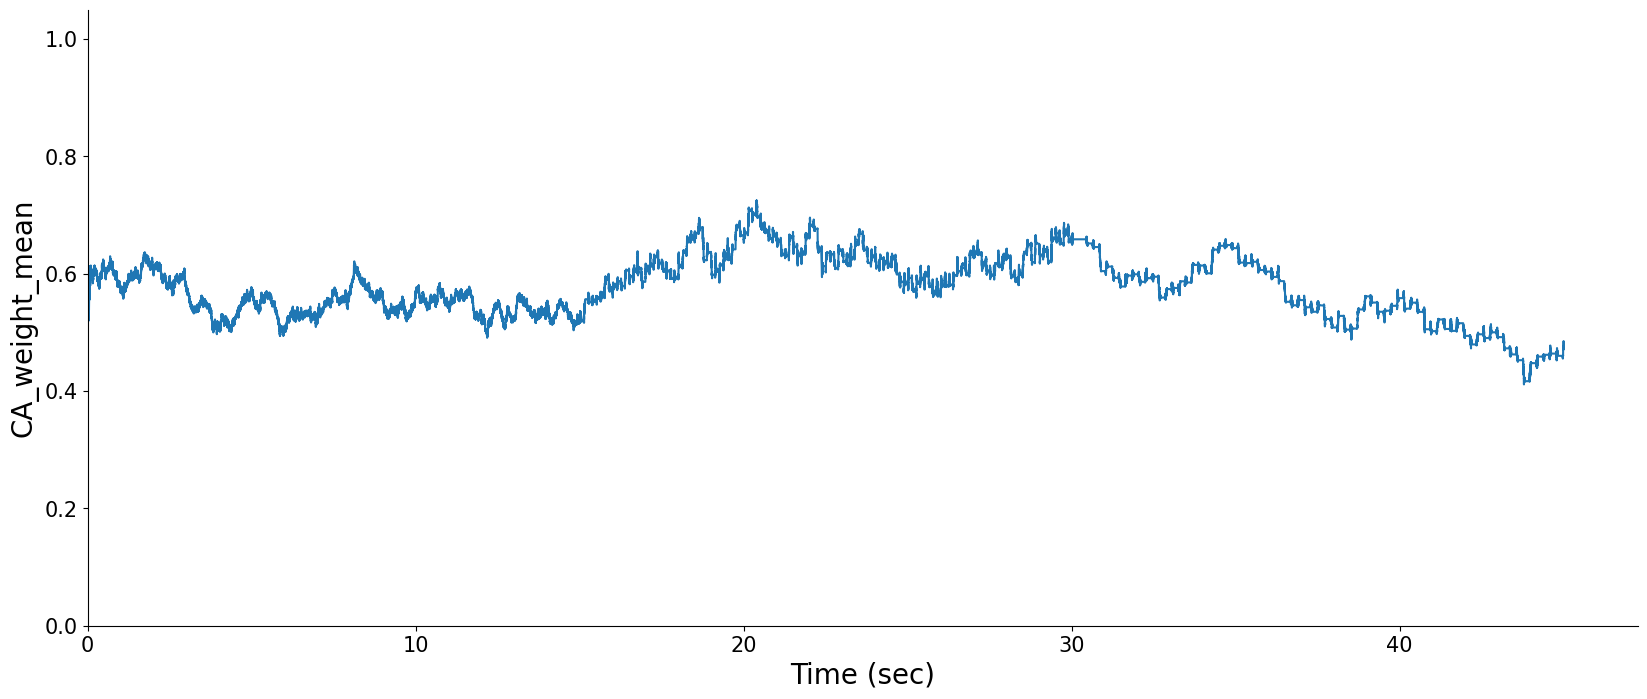

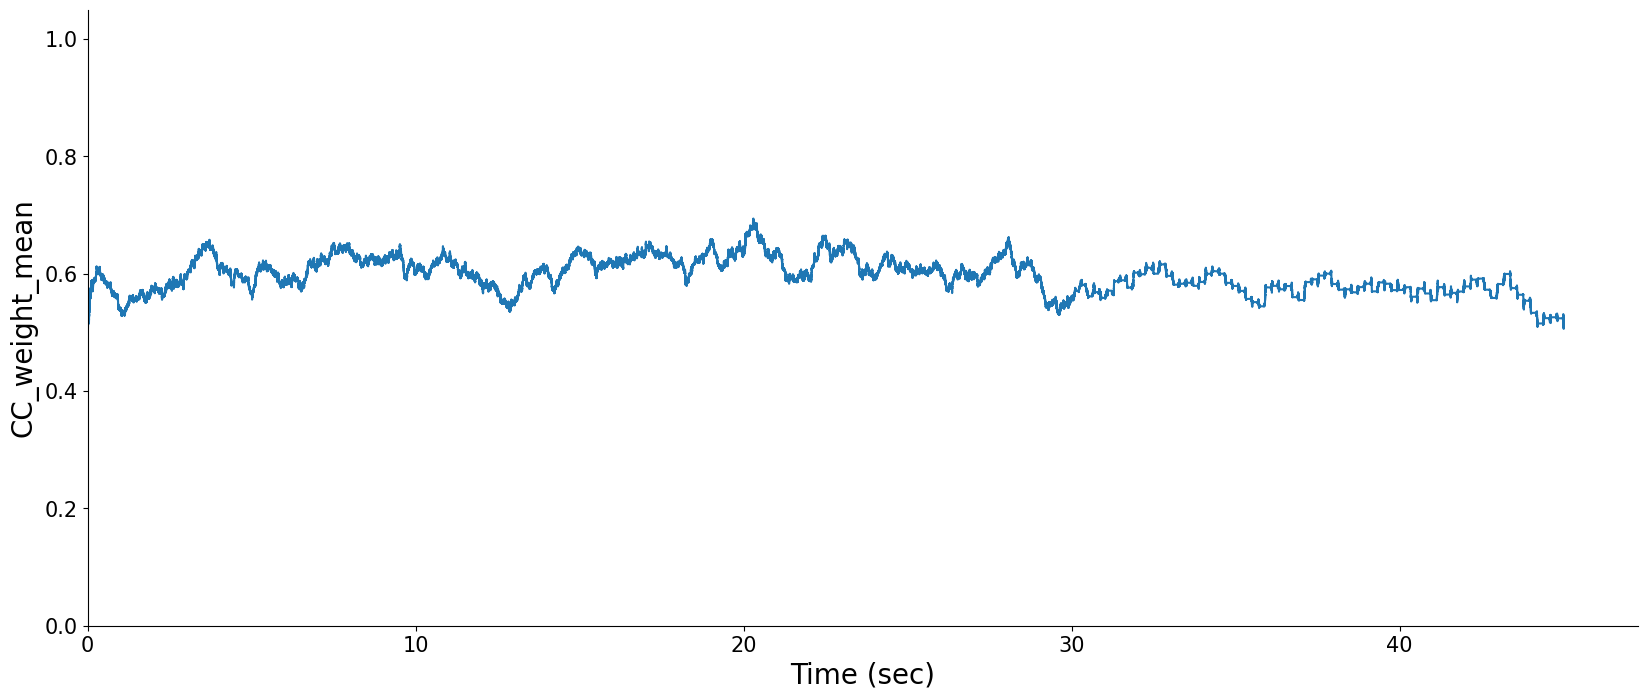

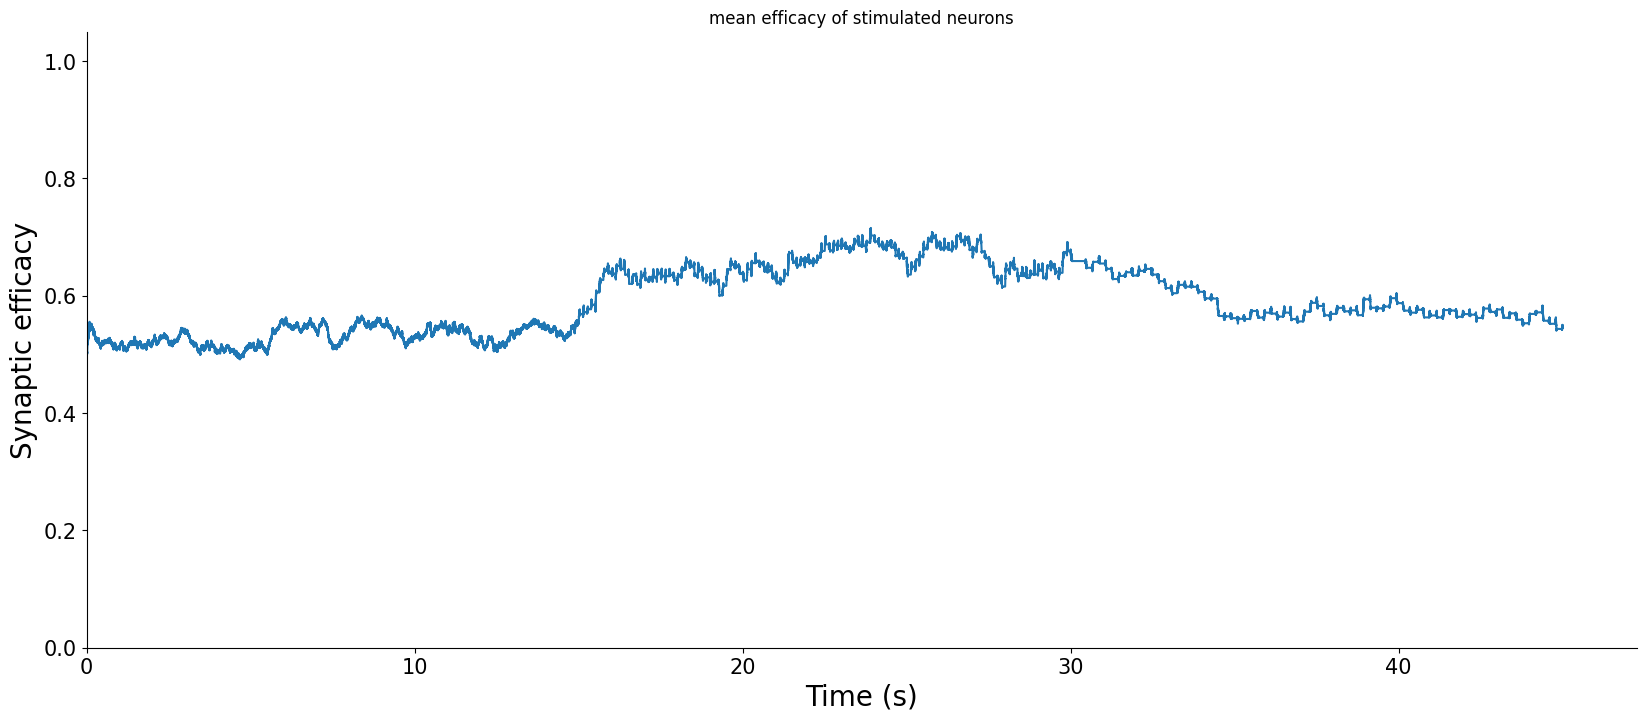

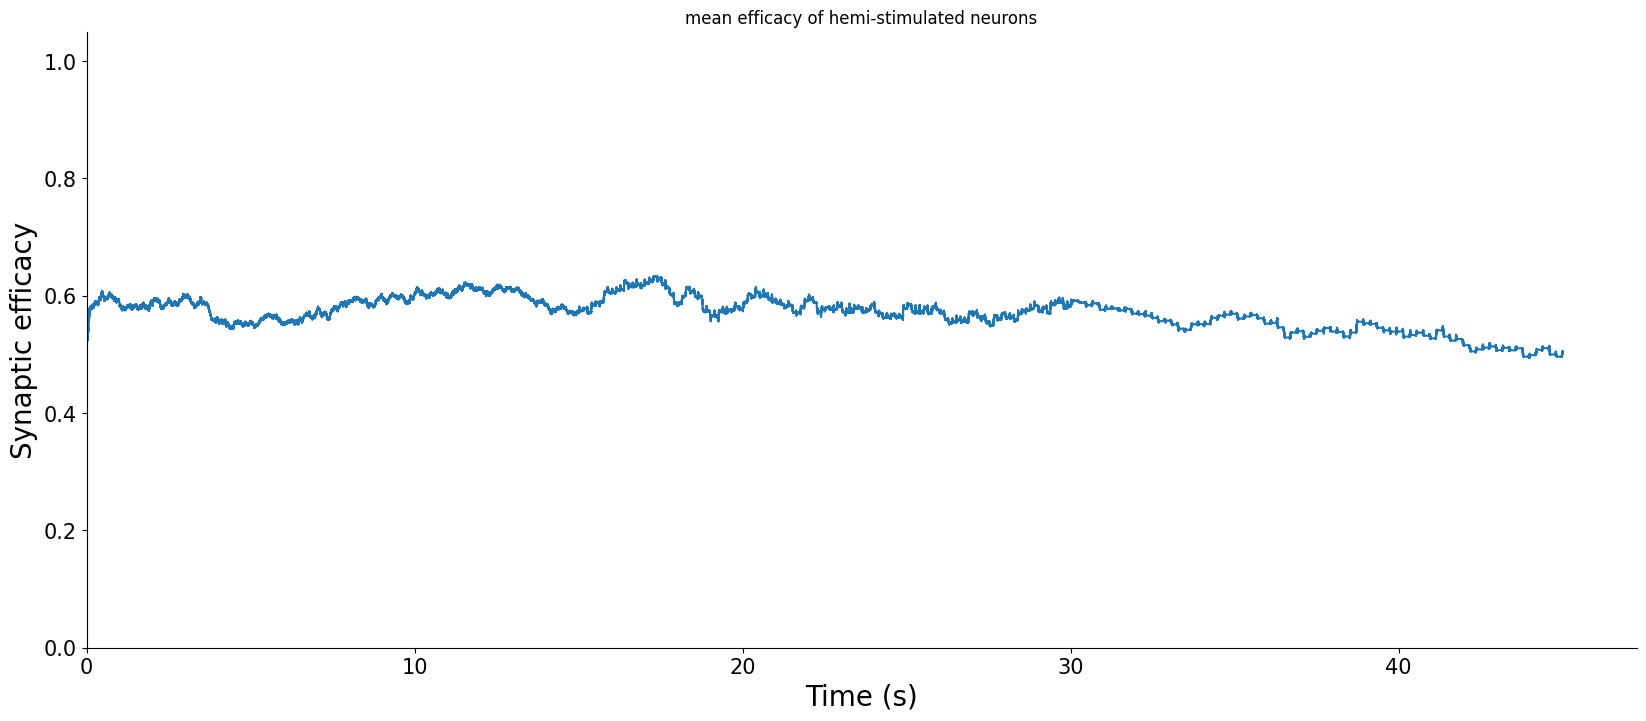

3024

In [10]:
#plot representative mean synaptic efficacy by groups

rdir="../AN_network/"
model_pre = "AN"
lr ="STDP"
lr_p= "a0.7t50th0.6"
op="_net_stim"
bifur = "cav"
date_i= "2023_3_10_1_7"

NE = 64  # number of excitatory neurons
Ip = 20  # ratio of inhibitory neurons 
Gex = 20  # number of neurons in a group
NI = int(NE*Ip/(100-Ip)) #number of inhibitory neurons
con_log = True  #True -> lognormal connections, False -> random connections
con_M = 1.0  # mean for the lognormal distribution of the number of synapses per excitatory neuron
con_M_in =  1.0 # mean for the lognormal distribution of the number of synapses per inhibitory neuron
log=0.01
con_ex_ex = log # SD for the lognormal distribution of the number of synapses in Ex-Ex connections
con_ex_in = log  # SD for the lognormal distribution of the number of synapses in Ex-In connections
con_in_in = log  # SD for the lognormal distribution of the number of synapses in In-In connections
con_in_ex = log  # SD for the lognormal distribution of the number of synapses in In-Ex connections


T = 45000  # ms  #total simulation time
Tp = 500
tbs = int(T/Tp)

T2 = 5000
Tp2=1000
ex=ex_in = -0.2   # original conductance* 10^(ex)   coefficient for wake state

stim_start=15000   #ms   time for start of stimulation

stim_dur= 15000 #ms  duration of stimulation protocol

stim_hz=20  #ms     Hz of stimulation

delay=0.0 #ms      stimulatiom delay bwtween pre and post-synaptic neurons

#parameters for stimulation waveform
dur =0.8
fy =-68#, -70, -65, -60]
ly=-76#, -80, -75]
vrest=-70
peak =4.89   #coefficients of peak voltage when stimulation


sws_start=0   #ms delay time after stimulation
sws_dur=15000  #ms duration of SWS
ex_s = 0.1  # original conductance* 10^(ex_s)   coefficient for sleep state

init = "r"
seed = 4
con_log = True

smin_ampa=0.5
smax_ampa=1.5


max_path ="stim_dir/{}{}_{}/param_{}/NE{}_NI{}_Gex{}/conM{}_conSD{}_conMin{}_conSDin{}/T_{}/ex{}_exin{}/stim{}_{}_{}hz_delay{}_{}_{}_{}_{}_{}/sws{}_{}_{}/sminampa{}_smaxampa{}_sws_stim.txt".format(model_pre, op, bifur, date_i, NE, NI, Gex, con_M, con_ex_ex, con_M_in, con_in_in, T, ex,ex, stim_start, stim_dur, stim_hz, delay, peak, dur, fy, ly, vrest,sws_start,sws_dur,ex_s, smin_ampa, smax_ampa)



ps =  max_path.split("/")
model_name = model_pre+ op +"_"+ bifur


stim_p = ps[7]

sws_p = ps[8]

drc = rdir+"/con_cu_i/{}/NE{}_NI{}_Gex{}/conM{}_conSD{}_conMin{}_conSDin{}/sminampa{}_smaxampa{}/{}_{}/{}/exs/{}/{}/{}/seed_{}/init_{}/T_{}/Tp_{}".format(model_name, NE,NI,Gex,con_M,con_ex_ex,con_M_in, con_in_in,smin_ampa, smax_ampa, lr, lr_p, date_i, ex, stim_p, sws_p, seed,  init, T, Tp)

drc_neu = drc+"/neu/"
drc_syn = drc + "/syn/"



dt=0.05  
syN=0
pairs = []
for post_i in range(NE+NI):
    for s in range(NE+NI):
        cpre_file = drc_syn+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+ "cpre"+str(s)+"-"+str(post_i)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
            pairs.append([s,post_i])
            syN += 1



con_mat = np.zeros((syN, int(T/dt)), dtype="float32") 
# offset = int(w/2)  #ms
c=0  
for i, pair in enumerate(pairs):
    s = pair[0]
    post_i = pair[1]
    for tb in range(tbs):
        # print(tb)
        rho_file = drc_syn+"ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+ "rho"+str(s)+"-"+str(post_i)+"_"+str(tb)+".bin"
        frho= open(rho_file, "rb")
        rectype = np.dtype(np.float64)
        rho_tb = np.fromfile(frho, dtype=rectype).astype("float32")
        # print(rho_tb)
        if tb==0:
            rho=rho_tb
        else:
            rho=np.append(rho, rho_tb).astype("float32")
        frho.close()

    con_mat[i] = rho
    del rho
    gc.collect()



x = np.arange(0, T, dt)/1000


#A->B
AB_cons = []
for pair in pairs:
    if pair[0]<Gex and Gex<=pair[1]<2*Gex:
        AB_cons.append(pair)

#A->A
AA_cons = []
for pair in pairs:
    if pair[0]<Gex and pair[1]<Gex:
        AA_cons.append(pair)

#B->A
BA_cons= []
for pair in pairs:
    if pair[1]<Gex and Gex<=pair[0]<2*Gex:
        BA_cons.append(pair)

#B->B
BB_cons= []
for pair in pairs:
    if Gex<=pair[1]<2*Gex and Gex<=pair[0]<2*Gex:
        BB_cons.append(pair)


#B->C
BC_cons = []
for pair in pairs:
    if Gex<=pair[0]<2*Gex and 2*Gex<=pair[1]:
        BC_cons.append(pair)

#C->B
CB_cons = []
for pair in pairs:
    if 2*Gex<=pair[0] and Gex<=pair[1]<2*Gex:
        CB_cons.append(pair)

#A-> C
AC_cons = []
for pair in pairs:
    if pair[0]<Gex and 2*Gex<=pair[1]:
        AC_cons.append(pair)

#C-> C
CC_cons = []
for pair in pairs:
    if 2*Gex<=pair[0] and 2*Gex<=pair[1]:
        CC_cons.append(pair)

#C->A
CA_cons= []
for pair in pairs:
    if pair[1]<Gex and 2*Gex<=pair[0]:
        CA_cons.append(pair)



#plot mean rho
AB_m =np.zeros((len(AB_cons),int(T/dt)), dtype="float32")
for n,AB_con in enumerate(AB_cons):
    conin = pairs.index(AB_con)
    AB_m[n]=con_mat[conin]
AB_mt=np.mean(AB_m, axis=0)

fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, AB_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('AB_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "AB"))
plt.show()

AB_1_m = (AB_mt[int((stim_start+stim_dur)/dt)])

last_AB_m = (AB_mt[-1])
AB_1_std = (np.std(AB_m, axis=0)/AB_mt)[int((stim_start+stim_dur)/dt)]
last_AB_std = (np.std(AB_m, axis=0)/AB_mt)[-1]

print(last_AB_m)
del AB_m
# del AB_mt
gc.collect()


AA_m =np.zeros((len(AA_cons),int(T/dt)), dtype="float32")
for n,AA_con in enumerate(AA_cons):
    conin = pairs.index(AA_con)
    AA_m[n]=con_mat[conin]
AA_mt=np.mean(AA_m, axis=0)

fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, AA_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('AA_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "AA"))
plt.show()
AA_1_m = (AA_mt[int((stim_start+stim_dur)/dt)])

last_AA_m = (AA_mt[-1])
AA_1_std = (np.std(AA_m, axis=0)/AA_mt)[int((stim_start+stim_dur)/dt)]
last_AA_std = (np.std(AA_m, axis=0)/AA_mt)[-1]

print(last_AA_m)
del AA_m
# del AB_mt
gc.collect()


BA_m =np.zeros((len(BA_cons),int(T/dt)), dtype="float32")
for n,BA_con in enumerate(BA_cons):
    conin = pairs.index(BA_con)
    BA_m[n]=con_mat[conin]
BA_mt=np.mean(BA_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, BA_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('BA_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "BA"))
plt.show()

BA_1_m = (BA_mt[int((stim_start+stim_dur)/dt)])
# BA_2_m = (BA_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_BA_m = (BA_mt[-1])
BA_1_std = (np.std(BA_m, axis=0)/BA_mt)[int((stim_start+stim_dur)/dt)]
last_BA_std = (np.std(BA_m, axis=0)/BA_mt)[-1]
del BA_m
# del BA_mt
gc.collect()


BB_m =np.zeros((len(BB_cons),int(T/dt)), dtype="float32")
for n,BB_con in enumerate(BB_cons):
    conin = pairs.index(BB_con)
    BB_m[n]=con_mat[conin]
BB_mt=np.mean(BB_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, BB_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('BB_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "BB"))
plt.show() 
BB_1_m = (BB_mt[int((stim_start+stim_dur)/dt)])
# BA_2_m = (BA_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_BB_m = (BB_mt[-1])
BB_1_std = (np.std(BB_m, axis=0)/BB_mt)[int((stim_start+stim_dur)/dt)]
last_BB_std = (np.std(BB_m, axis=0)/BB_mt)[-1]
del BB_m
# del BA_mt
gc.collect()



BC_m =np.zeros((len(BC_cons),int(T/dt)), dtype="float32")
for n,BC_con in enumerate(BC_cons):
    conin = pairs.index(BC_con)
    BC_m[n]=con_mat[conin]
BC_mt=np.mean(BC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, BC_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('BC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "BC"))
plt.show()
BC_1_m = (BC_mt[int((stim_start+stim_dur)/dt)])
# BC_2_m = (BC_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_BC_m = (BC_mt[-1])
BC_1_std = (np.std(BC_m, axis=0)/BC_mt)[int((stim_start+stim_dur)/dt)]
last_BC_std = (np.std(BC_m, axis=0)/BC_mt)[-1]
del BC_m
# del BC_mt
gc.collect()




CB_m =np.zeros((len(CB_cons),int(T/dt)), dtype="float32")
for n,CB_con in enumerate(CB_cons):
    conin = pairs.index(CB_con)
    CB_m[n]=con_mat[conin]
CB_mt=np.mean(CB_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CB_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('CB_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CB"))
plt.show()
CB_1_m = (CB_mt[int((stim_start+stim_dur)/dt)])
# CB_2_m = (CB_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_CB_m = (CB_mt[-1])
CB_1_std = (np.std(CB_m, axis=0)/CB_mt)[int((stim_start+stim_dur)/dt)]
last_CB_std = (np.std(CB_m, axis=0)/CB_mt)[-1]
del CB_m
# del CB_mt
gc.collect()


AC_m =np.zeros((len(AC_cons),int(T/dt)), dtype="float32")
for n,AC_con in enumerate(AC_cons):
    conin = pairs.index(AC_con)
    AC_m[n]=con_mat[conin]
AC_mt=np.mean(AC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, AC_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('AC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "AC"))
plt.show() 
AC_1_m = (AC_mt[int((stim_start+stim_dur)/dt)])
# AC_2_m = (AC_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_AC_m = (AC_mt[-1])
AC_1_std = (np.std(AC_m, axis=0)/AC_mt)[int((stim_start+stim_dur)/dt)]
last_AC_std = (np.std(AC_m, axis=0)/AC_mt)[-1]
del AC_m
# del AC_mt
gc.collect()




CA_m =np.zeros((len(CA_cons),int(T/dt)), dtype="float32")
for n,CA_con in enumerate(CA_cons):

    conin = pairs.index(CA_con)
    CA_m[n]=con_mat[conin]
CA_mt=np.mean(CA_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CA_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('CA_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CA"))
plt.show() 
CA_1_m = (CA_mt[int((stim_start+stim_dur)/dt)])
last_CA_m = (CA_mt[-1])
CA_1_std = (np.std(CA_m, axis=0)/CA_mt)[int((stim_start+stim_dur)/dt)]
last_CA_std = (np.std(CA_m, axis=0)/CA_mt)[-1]
del CA_m
# del CA_mt 
gc.collect()


CC_m =np.zeros((len(CC_cons),int(T/dt)), dtype="float32")
for n,CC_con in enumerate(CC_cons):

    conin = pairs.index(CC_con)
    CC_m[n]=con_mat[conin]
CC_mt=np.mean(CC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CC_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('CC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CC"))
plt.show()  
CC_1_m = (CC_mt[int((stim_start+stim_dur)/dt)])
last_CC_m = (CC_mt[-1])
CC_1_std = (np.std(CC_m, axis=0)/CC_mt)[int((stim_start+stim_dur)/dt)]
last_CC_std = (np.std(CC_m, axis=0)/CC_mt)[-1]
del CC_m
del CC_mt 
gc.collect()


#mean weight of stimed pair
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, (AB_mt+BA_mt+AA_mt+BB_mt)/4)
axes.set_title("mean efficacy of stimulated neurons")
axes.set_xlabel('Time (s)',fontsize = fs)
axes.set_ylabel('Synaptic efficacy',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "stimed"))
plt.show() 
del AA_mt
del AB_mt
del BB_mt
del BA_mt
gc.collect()


fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, (AC_mt+CA_mt+CB_mt+BC_mt)/4)
axes.set_title("mean efficacy of hemi-stimulated neurons")
axes.set_xlabel('Time (s)',fontsize = fs)
axes.set_ylabel('Synaptic efficacy',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
# axes.axes.xaxis.set_ticklabels([])
# axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "hemi-stimed"))
plt.show()

del AC_mt
del CB_mt
del BC_mt
del CA_mt
gc.collect()

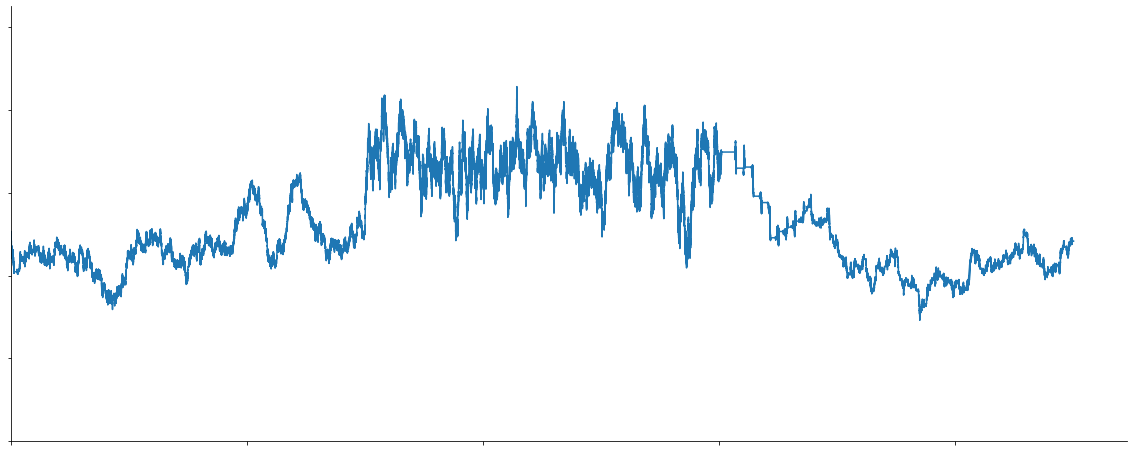

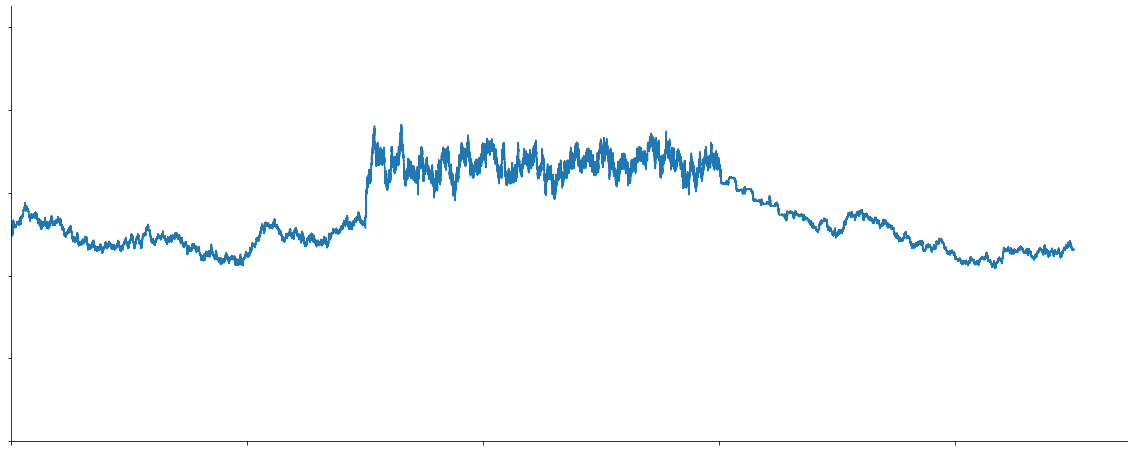

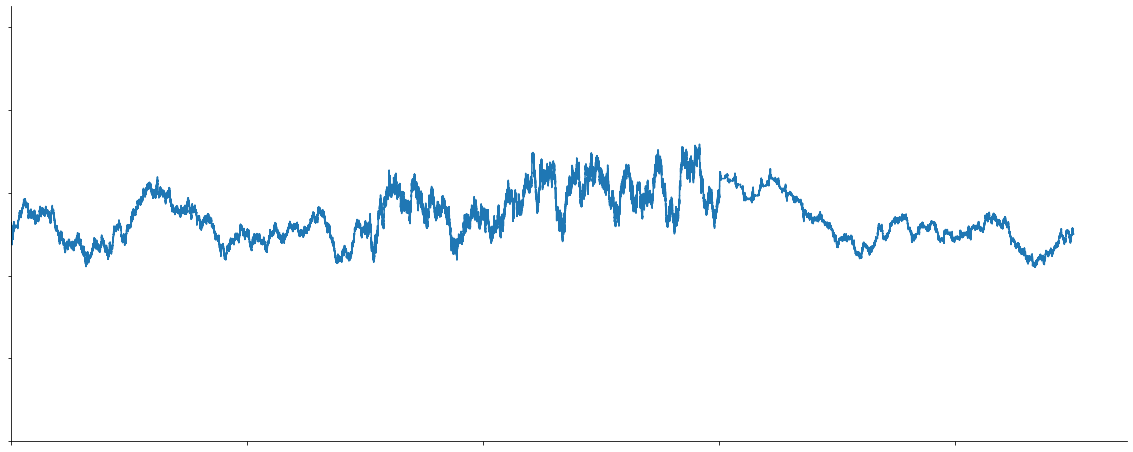

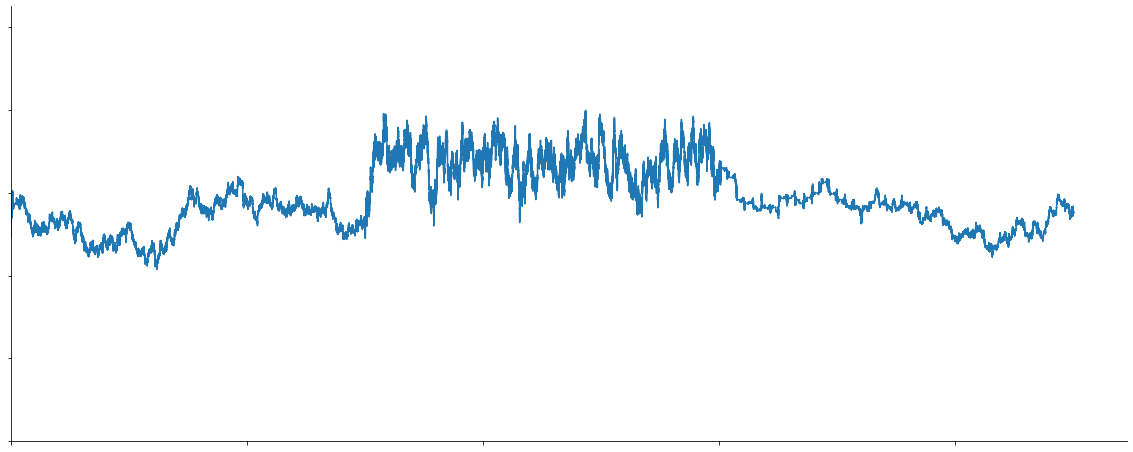

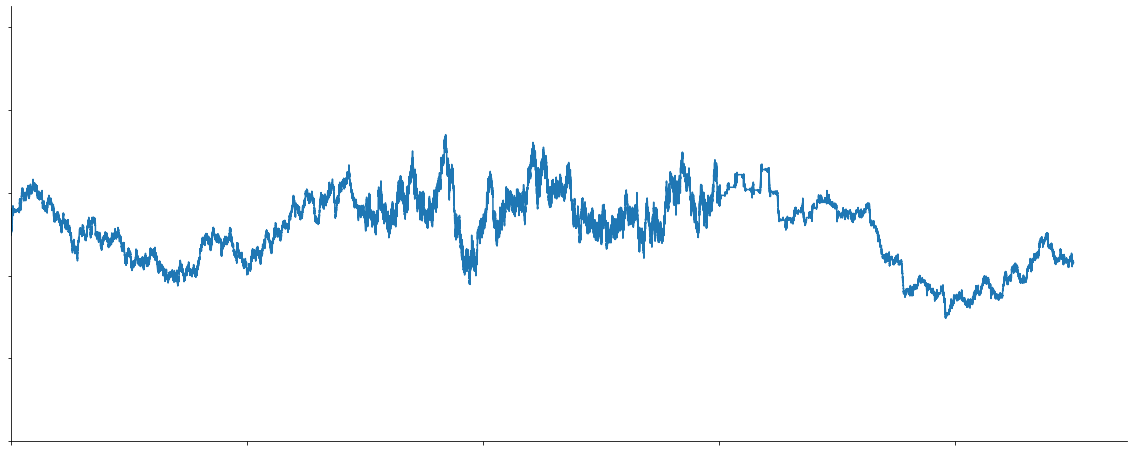

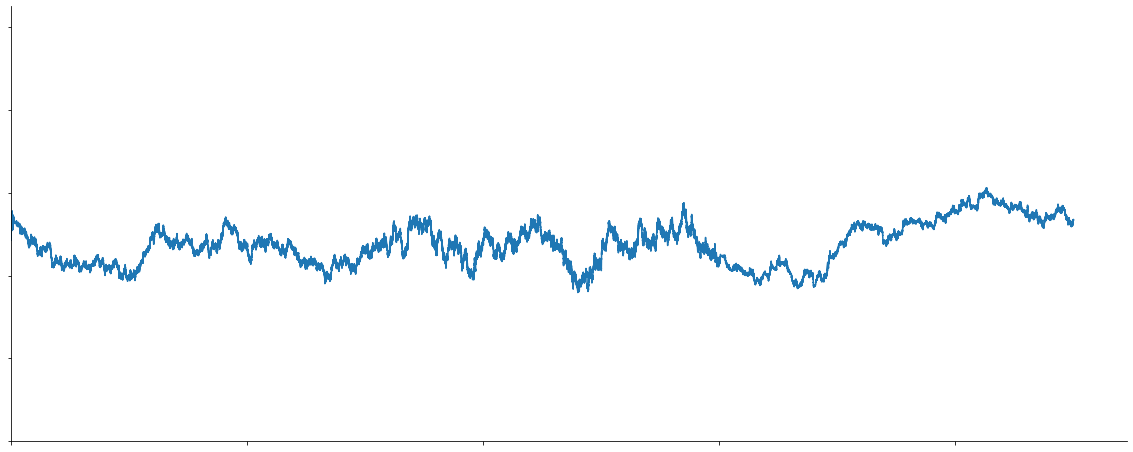

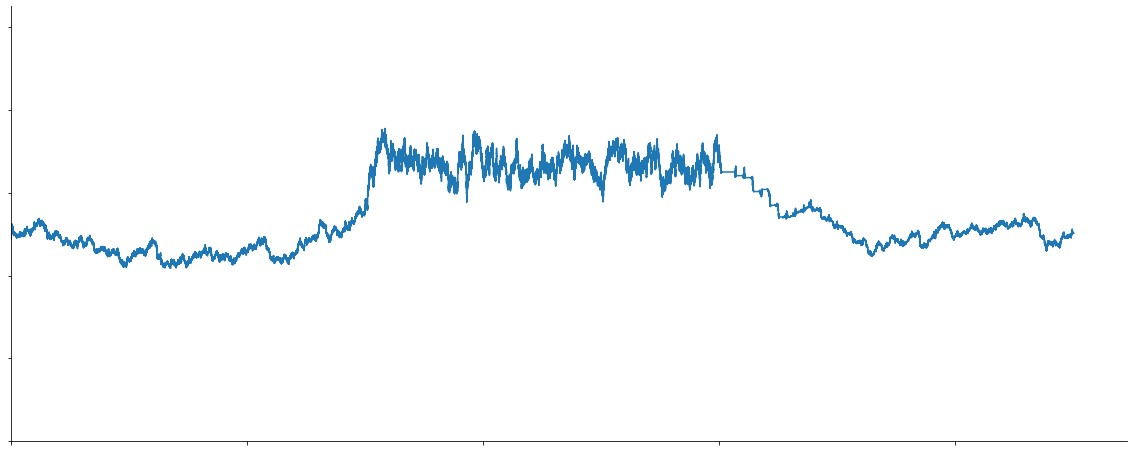

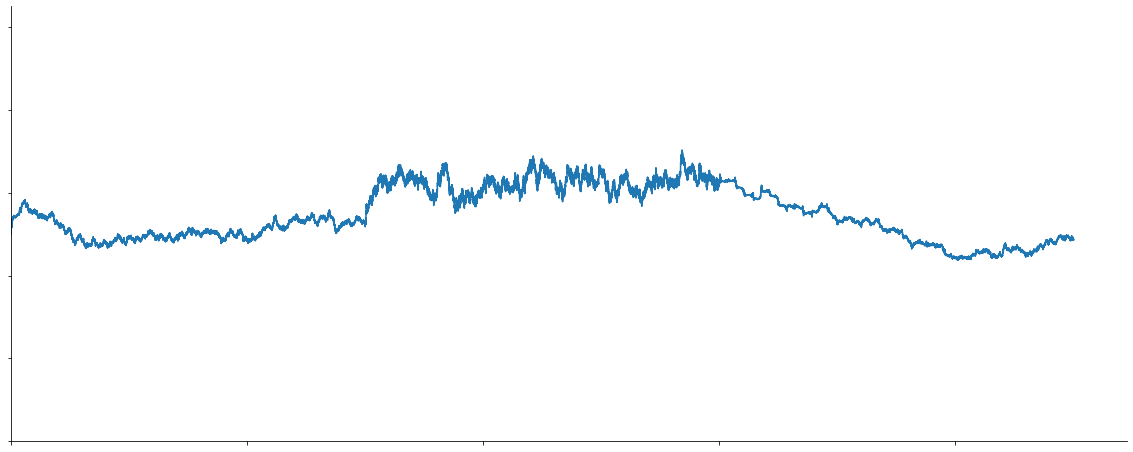

2728

In [6]:
BB_m =np.zeros((len(BB_cons),int(T/dt)), dtype="float32")
for n,BB_con in enumerate(BB_cons):
    conin = pairs.index(BB_con)
    BB_m[n]=con_mat[conin]
BB_mt=np.mean(BB_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, BB_mt)
axes.set_xlabel('Time (sec)',fontsize = fs)
axes.set_ylabel('BB_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "BB"))
plt.show() 
BB_1_m = (BB_mt[int((stim_start+stim_dur)/dt)])
# BA_2_m = (BA_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_BB_m = (BB_mt[-1])
BB_1_std = (np.std(BB_m, axis=0)/BB_mt)[int((stim_start+stim_dur)/dt)]
last_BB_std = (np.std(BB_m, axis=0)/BB_mt)[-1]
del BB_m
# del BA_mt
gc.collect()



BC_m =np.zeros((len(BC_cons),int(T/dt)), dtype="float32")
for n,BC_con in enumerate(BC_cons):
    conin = pairs.index(BC_con)
    BC_m[n]=con_mat[conin]
BC_mt=np.mean(BC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, BC_mt)
#     axes.set_xlabel('Time (sec)',fontsize = fs)
#     axes.set_ylabel('BC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "BC"))
plt.show()
BC_1_m = (BC_mt[int((stim_start+stim_dur)/dt)])
# BC_2_m = (BC_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_BC_m = (BC_mt[-1])
BC_1_std = (np.std(BC_m, axis=0)/BC_mt)[int((stim_start+stim_dur)/dt)]
last_BC_std = (np.std(BC_m, axis=0)/BC_mt)[-1]
del BC_m
# del BC_mt
gc.collect()




CB_m =np.zeros((len(CB_cons),int(T/dt)), dtype="float32")
for n,CB_con in enumerate(CB_cons):
    conin = pairs.index(CB_con)
    CB_m[n]=con_mat[conin]
CB_mt=np.mean(CB_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CB_mt)
#     axes.set_xlabel('Time (sec)',fontsize = fs)
#     axes.set_ylabel('CB_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CB"))
plt.show()
CB_1_m = (CB_mt[int((stim_start+stim_dur)/dt)])
# CB_2_m = (CB_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_CB_m = (CB_mt[-1])
CB_1_std = (np.std(CB_m, axis=0)/CB_mt)[int((stim_start+stim_dur)/dt)]
last_CB_std = (np.std(CB_m, axis=0)/CB_mt)[-1]
del CB_m
# del CB_mt
gc.collect()


AC_m =np.zeros((len(AC_cons),int(T/dt)), dtype="float32")
for n,AC_con in enumerate(AC_cons):
    conin = pairs.index(AC_con)
    AC_m[n]=con_mat[conin]
AC_mt=np.mean(AC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, AC_mt)
#     axes.set_xlabel('Time (sec)',fontsize = fs)
#     axes.set_ylabel('AC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "AC"))
plt.show() 
AC_1_m = (AC_mt[int((stim_start+stim_dur)/dt)])
# AC_2_m = (AC_mt[int((stim_start+interval+2*stim_dur)/dt)])
last_AC_m = (AC_mt[-1])
AC_1_std = (np.std(AC_m, axis=0)/AC_mt)[int((stim_start+stim_dur)/dt)]
last_AC_std = (np.std(AC_m, axis=0)/AC_mt)[-1]
del AC_m
# del AC_mt
gc.collect()




CA_m =np.zeros((len(CA_cons),int(T/dt)), dtype="float32")
for n,CA_con in enumerate(CA_cons):

    conin = pairs.index(CA_con)
    CA_m[n]=con_mat[conin]
CA_mt=np.mean(CA_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CA_mt)
#     axes.set_xlabel('Time (sec)',fontsize = fs)
#     axes.set_ylabel('CA_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CA"))
plt.show() 
CA_1_m = (CA_mt[int((stim_start+stim_dur)/dt)])
last_CA_m = (CA_mt[-1])
CA_1_std = (np.std(CA_m, axis=0)/CA_mt)[int((stim_start+stim_dur)/dt)]
last_CA_std = (np.std(CA_m, axis=0)/CA_mt)[-1]
del CA_m
# del CA_mt 
gc.collect()


CC_m =np.zeros((len(CC_cons),int(T/dt)), dtype="float32")
for n,CC_con in enumerate(CC_cons):

    conin = pairs.index(CC_con)
    CC_m[n]=con_mat[conin]
CC_mt=np.mean(CC_m, axis=0)
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, CC_mt)
#     axes.set_xlabel('Time (sec)',fontsize = fs)
#     axes.set_ylabel('CC_weight_mean',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "CC"))
plt.show()  
CC_1_m = (CC_mt[int((stim_start+stim_dur)/dt)])
last_CC_m = (CC_mt[-1])
CC_1_std = (np.std(CC_m, axis=0)/CC_mt)[int((stim_start+stim_dur)/dt)]
last_CC_std = (np.std(CC_m, axis=0)/CC_mt)[-1]
del CC_m
del CC_mt 
gc.collect()


#mean weight of stimed pair
fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, (AB_mt+BA_mt+AA_mt+BB_mt)/4)
#     axes.set_title("mean efficacy of stimulated neurons")
#     axes.set_xlabel('Time (s)',fontsize = fs)
#     axes.set_ylabel('Synaptic efficacy',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "stimed"))
plt.show() 
del AA_mt
del AB_mt
del BB_mt
del BA_mt
gc.collect()


fig, axes = plt.subplots(figsize=(20, 8))
axes.plot(x, (AC_mt+CA_mt+CB_mt+BC_mt)/4)
#     axes.set_title("mean efficacy of hemi-stimulated neurons")
#     axes.set_xlabel('Time (s)',fontsize = fs)
#     axes.set_ylabel('Synaptic efficacy',fontsize = fs)
axes.tick_params(labelsize=fs_l)
axes.set_ylim(0, 1.05)
axes.set_xlim(0,)
axes.axes.xaxis.set_ticklabels([])
axes.axes.yaxis.set_ticklabels([])
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_{}_{}_mrho.SVG".format(model_name, date_i, NE+NI, ex, lr, "hemi-stimed"))
plt.show()

del AC_mt
del CB_mt
del BC_mt
del CA_mt
gc.collect()

['ratio_sws_stim:0.809507440241527\n', 'diff_sws_stim:-0.1288832426071167\n', 'ratio_sws_nstim:0.8559064753397165\n', 'diff_sws_nstim:-0.0844348669052124\n', 'ratio_sws_nn:0.9091394543647766\n', 'diff_sws_nn:-0.05087023973464966\n']


[0.809507440241527, 0.9091394543647766]


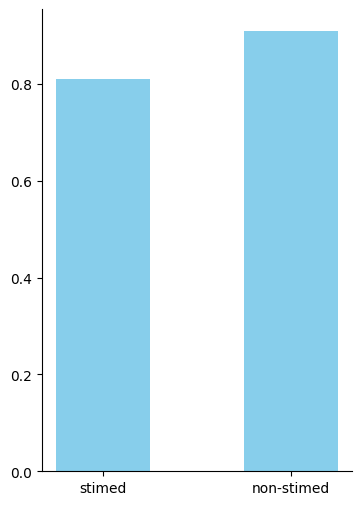

In [21]:

#ratio of efficacy before/after SWO between stimulated and no-stimulated

f = open(rdir + max_path, "r")
data = f.readlines()
print(data)
values = []
for n, line in enumerate(data):
    line = line.strip()
    key = line.split(":")[0]
    v = line.split(":")[1]
    if n==0 or n==4:
        values.append(float(v))
print(values)

x = ["stimed", "non-stimed"]

plt.figure(figsize=(4,6))
plt.bar(x, values, color="skyblue", width = 0.5)
plt.xlabel('',fontsize = fs)
# plt.ylabel('synaptic change (after sleep/before sleep)', fontsize = fs)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.yticks(np.arange(0,0.505, 0.1))
plt.ylim(0,)


ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)



plt.savefig("{}_{}_N{}_ex{}_{}_ratio_swo.SVG".format(model_name, date_i, NE+NI, ex, lr))
plt.show()